## Load Data


In [14]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd

In [16]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
  
# data (as pandas dataframes) 
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 

df = X.copy()
df["Diabetes_binary"] = y

# metadata 
print(cdc_diabetes_health_indicators.metadata) 
  
# variable information 
print(cdc_diabetes_health_indicators.variables) 


{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

In [17]:
df.columns

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'Diabetes_binary'],
      dtype='object')

## Define outcome/treatment variable/confounders

In [18]:
outcome = "Diabetes_binary"
treatment = "PhysActivity"

confounders = [
    "BMI",
    "HighBP",
    "HighChol",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "GenHlth",
    "PhysHlth",
    "MentHlth",
    "DiffWalk",
    "Age",
    "Education",
    "Income"
]

## estimate propensity score using logistic regression

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

ps_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=1000))
])

ps_model.fit(df[confounders], df[treatment])

df["propensity_score"] = ps_model.predict_proba(df[confounders])[:, 1]

In [20]:
df["propensity_score"].describe()

count    253680.000000
mean          0.756542
std           0.148735
min           0.057216
25%           0.697964
50%           0.804713
75%           0.864120
max           0.941185
Name: propensity_score, dtype: float64

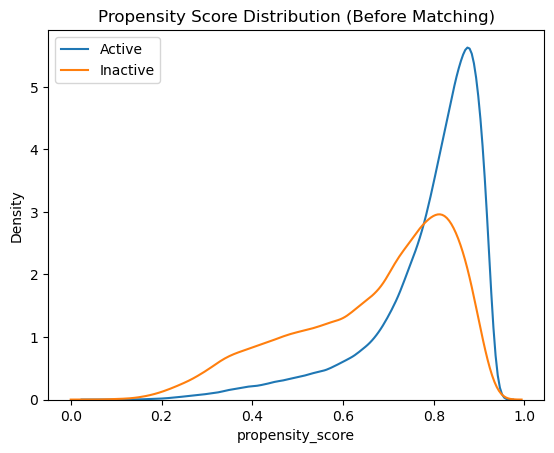

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df[df["PhysActivity"]==1]["propensity_score"], label="Active")
sns.kdeplot(df[df["PhysActivity"]==0]["propensity_score"], label="Inactive")

plt.title("Propensity Score Distribution (Before Matching)")
plt.legend()
plt.show()

## treated / control group

In [21]:
treated = df[df[treatment] == 1].copy()
control = df[df[treatment] == 0].copy()

print(treated.shape)
print(control.shape)

(191920, 23)
(61760, 23)


## Nearest neighbor matching

In [22]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["propensity_score"]])

distances, indices = nn.kneighbors(treated[["propensity_score"]])

matched_control = control.iloc[indices.flatten()].copy()
matched_treated = treated.copy()

matched_control["match_distance"] = distances.flatten()
matched_treated["match_distance"] = distances.flatten()

matched_df = pd.concat([matched_treated, matched_control], axis=0)

matched_df.shape

(383840, 24)

## add caliper to matching

In [23]:
caliper = 0.05

matched_treated_caliper = matched_treated[matched_treated["match_distance"] <= caliper]
matched_control_caliper = matched_control[matched_control["match_distance"] <= caliper]

matched_df = pd.concat(
    [matched_treated_caliper, matched_control_caliper],
    axis=0
)

matched_df.shape

(383840, 24)

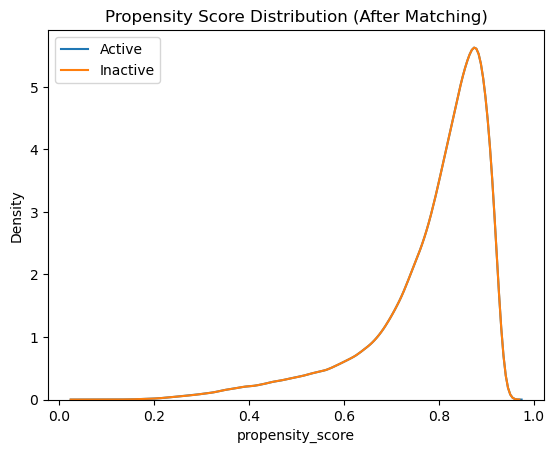

In [32]:
sns.kdeplot(matched_df[matched_df["PhysActivity"]==1]["propensity_score"], label="Active")
sns.kdeplot(matched_df[matched_df["PhysActivity"]==0]["propensity_score"], label="Inactive")

plt.title("Propensity Score Distribution (After Matching)")
plt.legend()
plt.show()

## check balance after matching

In [24]:
def standardized_mean_difference(data, variable, treatment_col):
    treated_vals = data[data[treatment_col] == 1][variable]
    control_vals = data[data[treatment_col] == 0][variable]
    
    mean_t = treated_vals.mean()
    mean_c = control_vals.mean()
    
    var_t = treated_vals.var()
    var_c = control_vals.var()
    
    pooled_sd = ((var_t + var_c) / 2) ** 0.5
    
    return (mean_t - mean_c) / pooled_sd


balance_before = []
balance_after = []

for var in confounders:
    smd_before = standardized_mean_difference(df, var, treatment)
    smd_after = standardized_mean_difference(matched_df, var, treatment)
    
    balance_before.append(smd_before)
    balance_after.append(smd_after)

balance_table = pd.DataFrame({
    "variable": confounders,
    "SMD_before": balance_before,
    "SMD_after": balance_after
})

balance_table

,variable,SMD_before,SMD_after
0,BMI,-0.328768,-0.008531
1,HighBP,-0.292676,0.020823
2,HighChol,-0.181502,0.009956
3,Smoker,-0.203768,0.019277
4,Stroke,-0.148060,0.000322
5,HeartDiseaseorAttack,-0.191191,0.016248
6,GenHlth,-0.625361,0.004831
7,PhysHlth,-0.466557,-0.005753
8,MentHlth,-0.269252,-0.001064
9,DiffWalk,-0.548063,-0.015499


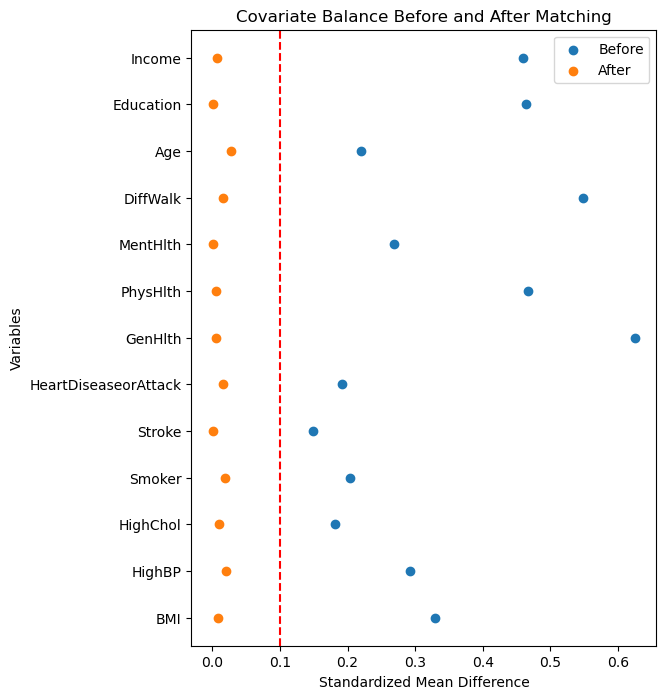

In [25]:
import matplotlib.pyplot as plt

balance_table["abs_before"] = balance_table["SMD_before"].abs()
balance_table["abs_after"] = balance_table["SMD_after"].abs()

plt.figure(figsize=(6,8))

plt.scatter(balance_table["abs_before"], balance_table["variable"], label="Before")
plt.scatter(balance_table["abs_after"], balance_table["variable"], label="After")

plt.axvline(0.1, linestyle="--", color="red")  # threshold

plt.xlabel("Standardized Mean Difference")
plt.ylabel("Variables")
plt.legend()
plt.title("Covariate Balance Before and After Matching")

plt.show()

## estimate diabetes rate after PSM


In [26]:
matched_df.groupby(treatment)[outcome].mean()

PhysActivity
0    0.119268
1    0.116127
Name: Diabetes_binary, dtype: float64

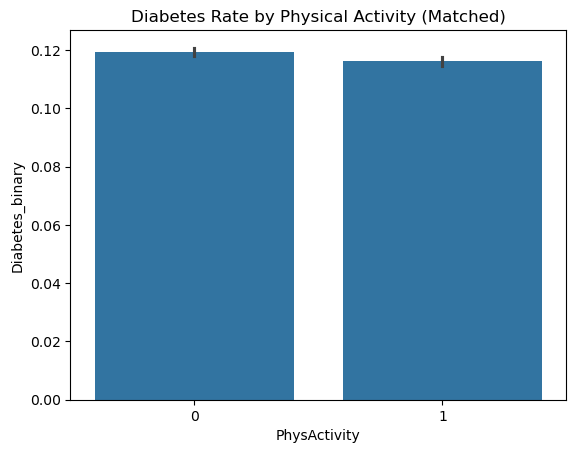

In [33]:
sns.barplot(
    x="PhysActivity",
    y="Diabetes_binary",
    data=matched_df
)

plt.title("Diabetes Rate by Physical Activity (Matched)")
plt.show()

In [27]:
rate_active = matched_df[matched_df[treatment] == 1][outcome].mean()
rate_inactive = matched_df[matched_df[treatment] == 0][outcome].mean()

risk_difference = rate_active - rate_inactive

print("Diabetes rate among active:", rate_active)
print("Diabetes rate among inactive:", rate_inactive)
print("Risk difference:", risk_difference)

Diabetes rate among active: 0.11612651104626928
Diabetes rate among inactive: 0.11926844518549395
Risk difference: -0.0031419341392246725


In [34]:
# before
before_active = df[df["PhysActivity"]==1]["Diabetes_binary"].mean()
before_inactive = df[df["PhysActivity"]==0]["Diabetes_binary"].mean()

# after
after_active = matched_df[matched_df["PhysActivity"]==1]["Diabetes_binary"].mean()
after_inactive = matched_df[matched_df["PhysActivity"]==0]["Diabetes_binary"].mean()

print("Before difference:", before_active - before_inactive)
print("After difference:", after_active - after_inactive)

Before difference: -0.09532102781383434
After difference: -0.0031419341392246725


## estimate effect using logistic regression 

In [28]:
import statsmodels.api as sm

X_psm = matched_df[[treatment]]
X_psm = sm.add_constant(X_psm)
y_psm = matched_df[outcome]

logit_psm = sm.Logit(y_psm, X_psm).fit()

print(logit_psm.summary())

Optimization terminated successfully.
         Current function value: 0.362300
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        Diabetes_binary   No. Observations:               383840
Model:                          Logit   Df Residuals:                   383838
Method:                           MLE   Df Model:                            1
Date:                Sat, 02 May 2026   Pseudo R-squ.:               3.280e-05
Time:                        11:17:35   Log-Likelihood:            -1.3907e+05
converged:                       True   LL-Null:                   -1.3907e+05
Covariance Type:            nonrobust   LLR p-value:                  0.002525
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.9994      0.007   -283.883      0.000      -2.013      -1.986
PhysActivity    -0.0303

## Odds ratio of diabetes for treated vs control group

In [29]:
import numpy as np

or_physactivity = np.exp(logit_psm.params[treatment])
ci = np.exp(logit_psm.conf_int().loc[treatment])

print("Odds Ratio for PhysActivity:", or_physactivity)
print("95% CI:", ci.values)

Odds Ratio for PhysActivity: 0.9701955294298555
95% CI: [0.95133094 0.98943419]
